# ETL del Conjunto de Datos

**Equipo:** Reto REHAB
**Fuente de datos:** `Data/Rehab_exercise/d01_raw_data/`
**Salida de este notebook:**

- `Data/Rehab_exercise/d03_clean_data/` — datos limpios (sin duplicados, sin muestras vacías, sin valores angulares imposibles), mismas unidades y forma que los crudos.

- `Data/Rehab_exercise/d04_transformed_data/` — datos limpios + transformados (suavizado y normalizados), listos para análisis/modelado.

- `Data/Rehab_exercise/manifest.csv` — metadatos por muestra (longitud real de señal, movimiento, extremidad, puntos reparados).

**Orden del pipeline (ETL):**
1. **Extract**: cargar los 32 archivos `.npy` crudos (16 movimientos × 2 grupos de sensores).

2. **Diagnóstico**: auditar calidad de datos crudos (faltantes, duplicados, padding, rangos físicamente válidos).

3. **Clean**: aplicar las correcciones que la auditoría justifica.

4. **Transform**: suavizado y normalización, aplicados **después** de limpiar (el orden importa — se explica en la Sección 4).

5. **Load**: guardar los arreglos limpios/transformados y el manifest de metadatos.


In [1]:
import os
import sys
import glob

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

sys.path.insert(0, os.path.abspath(".."))  # utils/ vive en la raiz del repo
from utils import etl_utils as u

In [2]:
RAW_DIR = os.path.join("..", "Data", "Rehab_exercise", "d01_raw_data")
CLEAN_DIR = os.path.join("..", "Data", "Rehab_exercise", "d03_clean_data")
TRANSFORMED_DIR = os.path.join("..", "Data", "Rehab_exercise", "d04_transformed_data")
MANIFEST_PATH = os.path.join("..", "Data", "Rehab_exercise", "manifest.csv")

os.makedirs(CLEAN_DIR, exist_ok=True)
os.makedirs(TRANSFORMED_DIR, exist_ok=True)

plt.rcParams["figure.dpi"] = 100        # resolucion (puntos por pulgada) de las figuras que se dibujen despues
np.set_printoptions(suppress=True)      # evita que numpy imprima numeros en notacion cientifica (mas facil de leer)

print("Movimientos en la librería:", u.N_MOVEMENTS)
print("Longitud de señal estandarizada:", u.SIGNAL_LENGTH)

Movimientos en la librería: 16
Longitud de señal estandarizada: 880


## 1. Extract

Cada archivo sigue el patrón `<movementID>_<sensorID>.npy` con forma `(d, 880, 6)`:

Ejemplo para confirmar la estructura antes de procesar los 32 archivos.


In [3]:
example = u.load_movement(RAW_DIR, movement_id=4, sensor_id=1)

print("Ejemplo movimiento 4, sensorID=1 -> shape:", example.shape, "dtype:", example.dtype)

Ejemplo movimiento 4, sensorID=1 -> shape: (287, 880, 6) dtype: float64


## 2. Auditoría de calidad de datos

Se calcula por archivo:

- **Valores faltantes/infinitos** (`NaN`/`Inf`).

- **Longitud de relleno (padding) final**: cuántos timesteps consecutivos al final de cada muestra son exactamente cero en los 6 canales a la vez para encontrar las señales más cortas.

- **Muestras 100% vacías**: toda la muestra es relleno (ninguna medición real).

- **Muestras duplicadas exactas**: secuencias `(880×6)` idénticas bit a bit dentro del mismo archivo.

- **Rango de valores por canal** (mínimo/máximo global).

In [4]:
def audit_file(path):
    """Calcula todas las metricas de calidad para UN archivo .npy crudo."""
    a = np.load(path)
    d, n, c = a.shape

    nan_inf = u.check_nan_inf(a)
    trail = u.compute_trailing_zero_length(a)
    empty = u.find_empty_samples(trail, n)
    dup = u.find_duplicate_sample_mask(a)

    return {
        "file": os.path.basename(path),                             # nombre del archivo
        "d": d,                                                     # numero de muestras
        "nan_count": nan_inf["nan_count"],                          # cuantos NaN
        "inf_count": nan_inf["inf_count"],                          # cuantos Inf
        "n_empty": int(empty.sum()),                                # cuantas muestras son 100% vacias
        "n_duplicate_extra": int(dup.sum()),                        # cuantos duplicadas
        "pct_padded_samples": float((trail > 0).mean() * 100),      # % de muestras con algo de padding
        "trail_mean": float(trail.mean()),                          # promedio de timesteps de padding por muestra en este archivo
        "channel_min": a.min(axis=(0, 1)),                          # minimo de cada canal
        "channel_max": a.max(axis=(0, 1)),                          # maximo de cada canal
    }

files = u.list_raw_files(RAW_DIR)
audit_rows = [audit_file(f) for f in files]
audit_df = pd.DataFrame(audit_rows)

print("Total de archivos auditados:", len(audit_df))
print("Total de muestras (todas las combinaciones movimiento x sensor):", audit_df["d"].sum())
print("Total NaN en todo el dataset crudo:", audit_df["nan_count"].sum())
print("Total Inf en todo el dataset crudo:", audit_df["inf_count"].sum())
print("Total de muestras 100% vacías:", audit_df["n_empty"].sum())
print("Total de renglones duplicados:", audit_df["n_duplicate_extra"].sum())

audit_df[["file", "d", "n_empty", "n_duplicate_extra", "pct_padded_samples", "trail_mean"]].head(10)

Total de archivos auditados: 32
Total de muestras (todas las combinaciones movimiento x sensor): 9232
Total NaN en todo el dataset crudo: 0
Total Inf en todo el dataset crudo: 0
Total de muestras 100% vacías: 142
Total de renglones duplicados: 1438


,file,d,n_empty,n_duplicate_extra,pct_padded_samples,trail_mean
0,000_1.npy,232,0,54,16.379310,28.431034
1,000_2.npy,232,0,54,16.810345,32.737069
2,001_1.npy,212,7,19,36.792453,102.051887
3,001_2.npy,212,7,19,39.150943,114.410377
4,002_1.npy,267,1,96,85.767790,233.606742
5,002_2.npy,267,1,96,84.644195,221.955056
6,003_1.npy,250,0,50,28.000000,46.868000
7,003_2.npy,250,0,50,34.800000,75.644000
8,004_1.npy,287,11,10,78.397213,221.682927
9,004_2.npy,287,11,10,70.034843,186.128920


In [5]:
# Rango de valores por tipo de canal.

ch1_min = np.vstack(
    [r["channel_min"] for r in audit_rows if r["file"].endswith("_1.npy")]
).min(axis=0)

ch1_max = np.vstack(
    [r["channel_max"] for r in audit_rows if r["file"].endswith("_1.npy")]
).max(axis=0)

ch2_min = np.vstack(
    [r["channel_min"] for r in audit_rows if r["file"].endswith("_2.npy")]
).min(axis=0)

ch2_max = np.vstack(
    [r["channel_max"] for r in audit_rows if r["file"].endswith("_2.npy")]
).max(axis=0)

range_df = pd.DataFrame({
    "canal": u.CHANNELS_SENSOR1 + u.CHANNELS_SENSOR2,
    "min_global": np.concatenate([ch1_min, ch2_min]),
    "max_global": np.concatenate([ch1_max, ch2_max]),
})

range_df["limite_matematico"] = ["±90"]*1 + ["±180","±180"] + ["±90"] + ["±180","±180"] + ["[0,~180]"]*5 + ["±180"]

range_df

,canal,min_global,max_global,limite_matematico
0,pitch1,-89.618000,89.71400,±90
1,yaw1,-1158.667000,367.22200,±180
2,roll1,-1178.349000,375.15600,±180
3,pitch2,-89.418000,89.62600,±90
4,yaw2,-683.630000,887.39300,±180
5,roll2,-497.796000,985.47400,±180
6,f1,0.000000,117.00000,"[0,~180]"
7,f2,0.000000,114.00000,"[0,~180]"
8,f3,0.000000,114.00000,"[0,~180]"
9,f4,0.000000,113.00000,"[0,~180]"


**Hallazgos de la auditoría:**

1. **0 valores `NaN` y 0 valores `Inf`** en los 32 archivos crudos.

2. **`pitch1` y `pitch2` siempre están dentro de `[-90°, 90°]`**, consistente con que se calculan mediante `arcsin`.

3. **`yaw1`, `roll1`, `yaw2`, `roll2` y `pitch3` alcanzan valores de hasta ~±1178°**, muy por fuera de el rango matemático de `arctan2`.

4. **`f1`–`f5` están siempre en `[0°, ~117°]`**, dentro del rango documentado del guante.

5. Existen **muestras 100% rellenas de ceros** y **muestras duplicadas exactas**.


## 3. Clean

Para que las muestras de `sensorID=1` y `sensorID=2` sigan correspondiendo al mismo ensayo/trial después de la limpieza, todas las decisiones de eliminación de muestras se aplican de forma conjunta: si la muestra `i` se elimina en cualquiera de los dos archivos de un movimiento, se elimina en ambos.


### 3.1 Valores faltantes / infinitos (`NaN` / `Inf`)

**Decisión: no se imputa nada.**

**Por qué:** la auditoría encontró **0 `NaN` y 0 `Inf`** en las 9,232 muestras crudas.


### 3.2 Muestras 100% vacías

**Decisión: eliminar por completo la muestra.**

**Por qué:** una muestra donde el 100% de los 880 timesteps son exactamente cero en los 6 canales simultáneamente no contiene ninguna medición real (falla de conexión/transmisión durante todo el trial). Conservarla puede sesgar cualquier estadística (media, varianza) hacia cero.


### 3.3 Muestras duplicadas exactas

**Decisión: eliminar todas las repeticiones de un patrón duplicado, conservando solo la primera ocurrencia.**

**Por qué:** se detectaron secuencias `(880×6)` idénticas bit a bit dentro del mismo archivo. Un sensor analógico muestreando a 50 Hz durante ~17 segundos jamás produce, en un ensayo físico real, exactamente la misma secuencia de 5,280 valores de punto flotante que otro ensayo. Mantener los duplicados sobre-representaría esos ensayos específicos en cualquier análisis o modelo.


### 3.4 Relleno (padding) parcial restante

**Decisión: no se recorta ni se rellena de otra forma — se calcula y se conserva la `valid_length` (longitud real de señal) de cada muestra, y se guarda en el manifest.**

**Por qué:** Hay muestras que tienen un relleno parcial al final (entre 16% y 86% de las muestras según el movimiento). Recortar cada muestra a su longitud real produciría arreglos de tamaño variable. En cambio, se calcula `valid_length` = 880 − (longitud de la corrida de ceros al final) para cada muestra.

La forma correcta de saber qué parte de una muestra es relleno es leer `valid_length` del manifest.


### 3.5 Valores angulares matemáticamente imposibles

**Decisión: detectar con un límite matemático exacto y reparar por interpolación lineal, sin descartar el ensayo completo.**

**Canales afectados:** `yaw1`, `roll1`, `yaw2`, `roll2` (sensorID=1) y `pitch3` (sensorID=2).

**Por qué:** Es una falla localizada en el tiempo, no un ensayo corrupto de principio a fin, el resto de los 880 puntos de esa muestra son información válida. Descartar la muestra completa desperdiciaría esa información, en cambio, se interpolan linealmente únicamente los puntos marcados como inválidos, usando los puntos válidos más cercanos dentro de la misma muestra.

A continuación se muestra un caso concreto que demuestra el problema


Muestra 124: valid_length=609, puntos marcados como invalidos=133


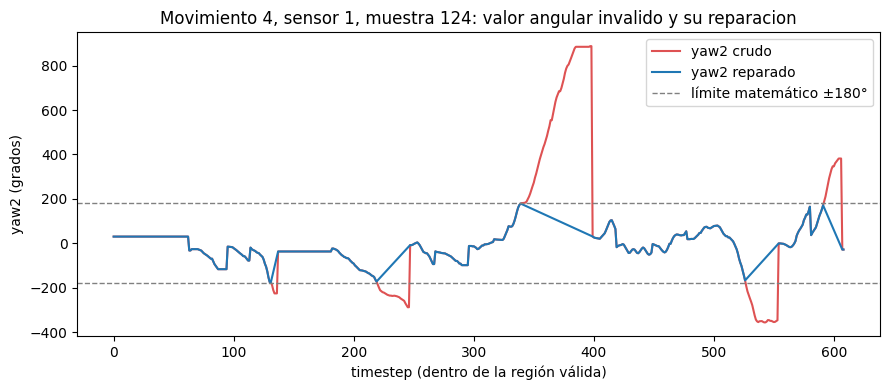

In [6]:
a4_1 = u.load_movement(RAW_DIR, movement_id=4, sensor_id=1)
trail4_1 = u.compute_trailing_zero_length(a4_1)
valid_len_4_1 = a4_1.shape[1] - trail4_1

yaw2_idx = u.CHANNELS_SENSOR1.index("yaw2")
x = a4_1[:, :, yaw2_idx]

repaired, mask = u.repair_spike_channel(x, valid_len_4_1)

sample_i = 124
vlen = int(valid_len_4_1[sample_i])

print(f"Muestra {sample_i}: valid_length={vlen}, puntos marcados como invalidos={mask[sample_i].sum()}")

fig, ax = plt.subplots(figsize=(9, 4))
t = np.arange(vlen)

ax.plot(t, x[sample_i, :vlen], label="yaw2 crudo", color="#d62728", alpha=0.8)

ax.plot(t, repaired[sample_i, :vlen], label="yaw2 reparado", color="#1f77b4", linewidth=1.5)

ax.axhline(180, color="gray", linestyle="--", linewidth=1, label="límite matemático ±180°")

ax.axhline(-180, color="gray", linestyle="--", linewidth=1)

ax.set_xlabel("timestep (dentro de la región válida)")
ax.set_ylabel("yaw2 (grados)")
ax.set_title(f"Movimiento 4, sensor 1, muestra {sample_i}: valor angular invalido y su reparacion")
ax.legend()
fig.tight_layout()
plt.show()

### 3.6 Pipeline de limpieza completo (los 16 movimientos)

Se aplica, para cada movimiento, en este orden:

1. Cargar `_1` y `_2`.

2. Calcular `valid_length` de cada uno.

3. Identificar muestras vacías y duplicadas en cualquiera de los dos archivos.

4. Eliminar esas muestras de ambos archivos.

5. Reparar los canales angulares afectados.


In [7]:
reports = []        # lista donde vamos a acumular una fila de resumen por cada uno de los 16 movimientos
clean_data = {}     # diccionario: movement_id -> {arrays ya limpios, sus valid_length, indices originales}

for m in range(u.N_MOVEMENTS):
    a1 = u.load_movement(RAW_DIR, m, 1)
    a2 = u.load_movement(RAW_DIR, m, 2)
    assert a1.shape[0] == a2.shape[0], f"movimiento {m}: sensor1 y sensor2 tienen distinto numero de muestras"

    n = a1.shape[1]                                  # longitud de señal
    trail1 = u.compute_trailing_zero_length(a1)      # (d,) padding al final de cada muestra, segun sensor 1
    trail2 = u.compute_trailing_zero_length(a2)      # (d,) padding al final de cada muestra, segun sensor 2
    valid_len1 = n - trail1                          # (d,) longitud real de señal segun sensor 1
    valid_len2 = n - trail2                          # (d,) longitud real de señal segun sensor 2

    # True si la muestra esta 100% vacia en sensor 1 o en sensor 2
    empty_mask = u.find_empty_samples(trail1, n) | u.find_empty_samples(trail2, n)

    # True si la muestra es duplicado exacto en sensor 1 o en sensor 2
    dup_mask = u.find_duplicate_sample_mask(a1) | u.find_duplicate_sample_mask(a2)

    drop_mask = empty_mask | dup_mask                # True si hay que eliminar la muestra por cualquiera de las dos razones
    keep_mask = ~drop_mask                           # True = conservar
    orig_idx = np.where(keep_mask)[0]                # indices de las muestras que si se conservan

    a1_k, a2_k = a1[keep_mask], a2[keep_mask]                           # crea copias nuevas solo con las muestras a conservar
    vlen1_k, vlen2_k = valid_len1[keep_mask], valid_len2[keep_mask]     # mismo filtro aplicado a los arreglos de longitud valida

    n_repaired_1 = 0
    for ch_name in u.SPIKE_CHANNELS_SENSOR1:
        ci = u.CHANNELS_SENSOR1.index(ch_name)
        repaired, mask = u.repair_spike_channel(a1_k[:, :, ci], vlen1_k)
        n_repaired_1 += int(mask.sum())
        a1_k[:, :, ci] = repaired

    n_repaired_2 = 0
    for ch_name in u.SPIKE_CHANNELS_SENSOR2:
        ci = u.CHANNELS_SENSOR2.index(ch_name)
        repaired, mask = u.repair_spike_channel(a2_k[:, :, ci], vlen2_k)
        n_repaired_2 += int(mask.sum())
        a2_k[:, :, ci] = repaired

    # guarda todos los datos limpios
    clean_data[m] = dict(a1=a1_k, a2=a2_k, vlen1=vlen1_k, vlen2=vlen2_k, orig_idx=orig_idx)

    name, limb = u.MOVEMENT_LIBRARY[m]
    reports.append(dict(
        movement_id=m, movement_name=name, limb=limb,
        n_raw=int(a1.shape[0]),
        n_empty_dropped=int(empty_mask.sum()),
        n_duplicate_dropped=int((dup_mask & ~empty_mask).sum()),
        n_kept=int(keep_mask.sum()),
        n_points_repaired_sensor1=n_repaired_1, n_points_repaired_sensor2=n_repaired_2,
        pct_kept=100 * keep_mask.sum() / a1.shape[0],
    ))

report_df = pd.DataFrame(reports)
report_df

,movement_id,movement_name,limb,n_raw,n_empty_dropped,n_duplicate_dropped,n_kept,n_points_repaired_sensor1,n_points_repaired_sensor2,pct_kept
0,0,Bobath handshake,upper,232,0,54,178,419,86,76.724138
1,1,Bobath flexion/extension,upper,212,7,13,192,0,240,90.566038
2,2,Bobath forward flexion/extension,upper,267,1,96,170,0,0,63.670412
3,3,Bobath anterior/posterior rotation,upper,250,0,50,200,0,79,80.000000
4,4,Elbow flexion and wrist compression,upper,287,11,0,276,3267,2,96.167247
5,5,Wrist flexion and extension,upper,293,12,3,278,0,116,94.880546
6,6,Finger-to-finger training,upper,260,3,46,211,0,0,81.153846
7,7,Ball gripping,upper,385,3,0,382,0,108,99.220779
8,8,Shoulder joint internal and external rotation,upper,299,0,0,299,4938,0,100.000000
9,9,Breast expansion,upper,307,0,0,307,1149,0,100.000000


In [8]:
print("Total de muestras crudas:", report_df["n_raw"].sum())
print("Total eliminadas por estar vacías:", report_df["n_empty_dropped"].sum())
print("Total eliminadas por ser duplicadas:", report_df["n_duplicate_dropped"].sum())
print("Total de muestras limpias conservadas:", report_df["n_kept"].sum())
print("Total de puntos individuales reparados (canales rotacionales, sensor 1):", report_df["n_points_repaired_sensor1"].sum())
print("Total de puntos individuales reparados (pitch3, sensor 2):", report_df["n_points_repaired_sensor2"].sum())

Total de muestras crudas: 4616
Total eliminadas por estar vacías: 74
Total eliminadas por ser duplicadas: 658
Total de muestras limpias conservadas: 3884
Total de puntos individuales reparados (canales rotacionales, sensor 1): 47806
Total de puntos individuales reparados (pitch3, sensor 2): 674


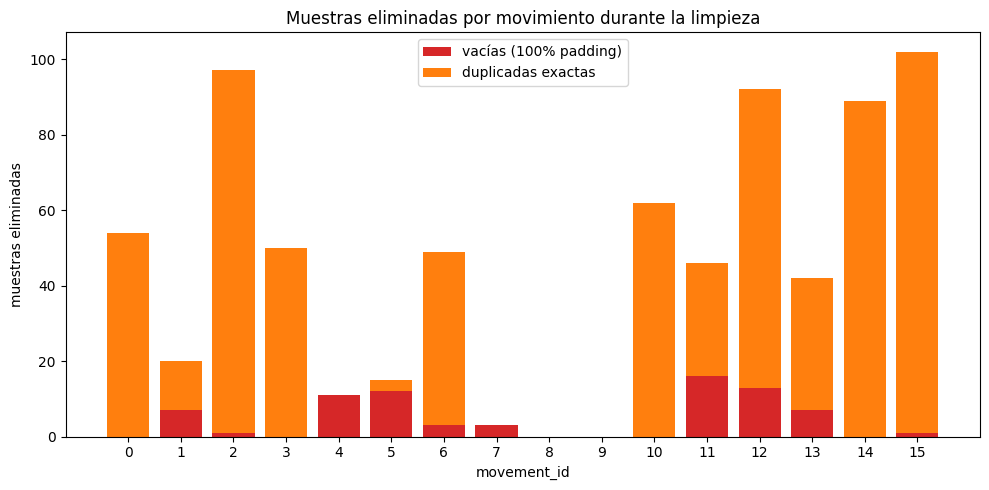

In [9]:
fig, ax = plt.subplots(figsize=(10, 5))
x = np.arange(u.N_MOVEMENTS)

ax.bar(x, report_df["n_empty_dropped"], label="vacías (100% padding)", color="#d62728")

ax.bar(x, report_df["n_duplicate_dropped"], bottom=report_df["n_empty_dropped"], label="duplicadas exactas", color="#ff7f0e")

ax.set_xticks(x)
ax.set_xticklabels(report_df["movement_id"])
ax.set_xlabel("movement_id")
ax.set_ylabel("muestras eliminadas")
ax.set_title("Muestras eliminadas por movimiento durante la limpieza")
ax.legend()
fig.tight_layout()
plt.show()

## 4. Transform

Se aplican, en este orden, sobre los datos ya limpios:

1. Suavizado por media móvil.
2. Normalización zero-mean/unit-variance por muestra y canal.

### 4.2 Suavizado por media móvil (ventana = 10)

**Decisión: aplicar un filtro de media móvil con ventana de 10 muestras, calculado únicamente sobre la región válida `[0, valid_length)` de cada muestra.**

**Por qué esta ventana:** se replica el mismo tamaño de ventana que usa el pipeline original del dataset para reducir inestabilidad y picos puntuales de los sensores IMU/flex, sin suavizar en exceso la dinámica del movimiento.

**Por qué solo sobre la región válida:** Arrastraría el valor 0 del relleno hacia los últimos puntos reales de la señal sesgando artificialmente la señal real hacia cero justo antes de que empiece el padding.

**Por qué la ventana se encoge en los bordes (en vez de rellenar con ceros):** cerca de los extremos de la región válida, una ventana de 10 muestras se sale de la señal real. Promediar eso con ceros implícitos (el comportamiento por defecto de una convolución) sesga justo esos puntos reales hacia 0 — el mismo problema que ya se evita para el padding, pero aplicado por accidente a señal real. `moving_average_valid` divide en cada posición entre la cantidad real de muestras que cayeron en la ventana, no siempre entre 10, para que los bordes promedien solo puntos reales.

### 4.3 Normalización zero-mean / unit-variance por muestra y canal

**Decisión: para cada muestra y cada canal, restar la media y dividir entre la desviación estándar, calculadas únicamente sobre su región válida `[0, valid_length)`.**

**Por qué por muestra y no de forma global:** el artículo original describe esta normalización como una forma de remover el *offset* de calibración/colocación propio de cada sensor y de cada paciente. Ese offset es específico de cada colocación del sensor, no un valor global compartido por todo el dataset, así que la normalización debe calcularse por muestra.

**Por qué solo sobre la región válida (y no sobre las 880 posiciones):** el padding es 0 por construcción; incluirlo en el cálculo de la media/desviación sesga ambas hacia 0, y el sesgo es mayor mientras más padding tenga la muestra.


In [10]:
transformed_data = {}

for m in range(u.N_MOVEMENTS):
    a1_k, a2_k = clean_data[m]["a1"], clean_data[m]["a2"]
    vlen1, vlen2 = clean_data[m]["vlen1"], clean_data[m]["vlen2"]

    a1_smooth = u.moving_average_valid(a1_k, vlen1, window=10)
    a2_smooth = u.moving_average_valid(a2_k, vlen2, window=10)

    a1_norm = u.zscore_normalize_valid(a1_smooth, vlen1)
    a2_norm = u.zscore_normalize_valid(a2_smooth, vlen2)

    transformed_data[m] = dict(a1=a1_norm, a2=a2_norm)

print("Transformación aplicada a los 16 movimientos (suavizado -> normalización).")

Transformación aplicada a los 16 movimientos (suavizado -> normalización).


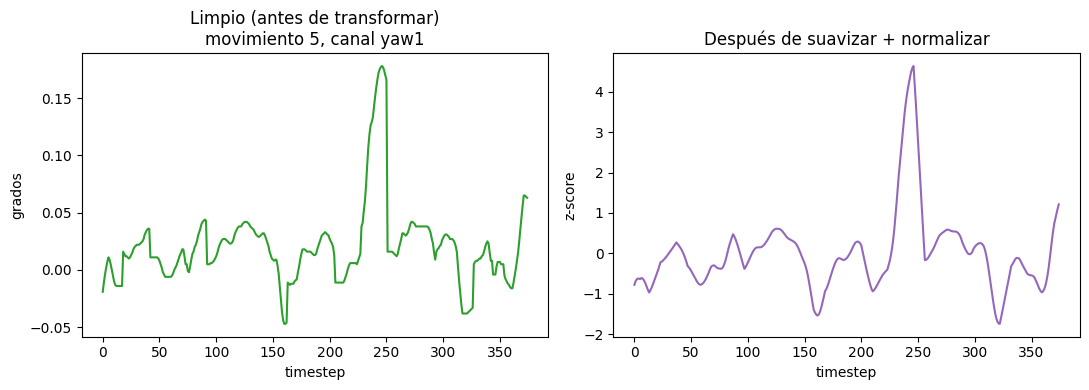

In [11]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4))
m, i, ch = 5, 100, 1
vlen = clean_data[m]["vlen1"][i]


axes[0].plot(clean_data[m]["a1"][i, :vlen, ch], color="#2ca02c")

axes[0].set_title(f"Limpio (antes de transformar)\nmovimiento {m}, canal {u.CHANNELS_SENSOR1[ch]}")
axes[0].set_xlabel("timestep")
axes[0].set_ylabel("grados")

axes[1].plot(transformed_data[m]["a1"][i, :vlen, ch], color="#9467bd")

axes[1].set_title("Después de suavizar + normalizar")
axes[1].set_xlabel("timestep")
axes[1].set_ylabel("z-score")

fig.tight_layout()
plt.show()

## 5. Load

Se guarda siguiendo la misma convención de nombres del dataset original (`<movementID>_<sensorID>.npy`), en dos carpetas nuevas dentro de `Data/Rehab_exercise/` que extienden la numeración ya usada (`d01_raw_data`, `d02_processed_data` eran del dataset original):

- **`d03_clean_data/`** → sin muestras vacías/duplicadas, ángulos imposibles reparados.

- **`d04_transformed_data/`** → suavizado + normalizado.

- **`manifest.csv`** → una fila por cada muestra conservada, con su `movement_id`, nombre, extremidad, índice original en el archivo crudo, y `valid_length` de cada grupo de sensor. Este archivo es la referencia autoritativa para saber qué parte de cada muestra es señal real y cuál es relleno.

In [12]:
manifest_rows = []

for m in range(u.N_MOVEMENTS):
    a1_k, a2_k = clean_data[m]["a1"], clean_data[m]["a2"]
    vlen1, vlen2 = clean_data[m]["vlen1"], clean_data[m]["vlen2"]
    orig_idx = clean_data[m]["orig_idx"]

    np.save(os.path.join(CLEAN_DIR, f"{m:03d}_1.npy"), a1_k)
    np.save(os.path.join(CLEAN_DIR, f"{m:03d}_2.npy"), a2_k)
    np.save(os.path.join(TRANSFORMED_DIR, f"{m:03d}_1.npy"), transformed_data[m]["a1"])
    np.save(os.path.join(TRANSFORMED_DIR, f"{m:03d}_2.npy"), transformed_data[m]["a2"])

    name, limb = u.MOVEMENT_LIBRARY[m]
    for new_i in range(a1_k.shape[0]):
        manifest_rows.append(dict(
            movement_id=m, movement_name=name, limb=limb,
            sample_index=new_i,
            orig_index_in_raw=int(orig_idx[new_i]),
            valid_length_sensor1=int(vlen1[new_i]), valid_length_sensor2=int(vlen2[new_i]),
        ))

manifest_df = pd.DataFrame(manifest_rows)
manifest_df.to_csv(MANIFEST_PATH, index=False)

print("Muestras totales en el manifest:", len(manifest_df))
print("Archivos escritos en:", os.path.abspath(CLEAN_DIR))
print("Archivos escritos en:", os.path.abspath(TRANSFORMED_DIR))
print("Manifest escrito en:", os.path.abspath(MANIFEST_PATH))
manifest_df.head()

Muestras totales en el manifest: 3884
Archivos escritos en: /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise/d03_clean_data
Archivos escritos en: /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise/d04_transformed_data
Manifest escrito en: /Users/baltazarservin/Documents/School/TEC/7mo_Semestre/Inteligencia Artificial/Reto/REHAB-RETO/Data/Rehab_exercise/manifest.csv


,movement_id,movement_name,limb,sample_index,orig_index_in_raw,valid_length_sensor1,valid_length_sensor2
0,0,Bobath handshake,upper,0,0,880,880
1,0,Bobath handshake,upper,1,1,880,880
2,0,Bobath handshake,upper,2,2,880,880
3,0,Bobath handshake,upper,3,3,777,880
4,0,Bobath handshake,upper,4,4,797,880


## 6. Resumen de decisiones

| Etapa | Atributo / canales | Decisión | Evidencia que la justifica |
|---|---|---|---|
| Limpieza | Todas las muestras | No imputar `NaN`/`Inf` | 0 encontrados en 9,232 muestras crudas (verificación defensiva se mantiene en el pipeline) |
| Limpieza | Todas las muestras | Eliminar muestras 100% relleno (conjunto entre `_1`/`_2`) | 142 muestras con `valid_length = 0` detectadas |
| Limpieza | Todas las muestras | Eliminar duplicados exactos, conservar 1ª ocurrencia (conjunto entre `_1`/`_2`) | 1,438 renglones duplicados bit-a-bit detectados vía `np.unique` |
| Limpieza | Todas las muestras | Conservar longitud 880 pero calcular y persistir `valid_length` por muestra y por sensor | Padding parcial varía 16%–86% de las muestras según movimiento; difiere entre `sensorID=1` y `sensorID=2` para el mismo trial |
| Limpieza | `yaw1, roll1, yaw2, roll2, pitch3` | Reparar por interpolación lineal los puntos con `\|valor\| > 180°` | `yaw`/`roll` se calculan con `arctan2` (rango matemático exacto `(-180°,180°]`); se observaron fallas sostenidas de sensor de hasta ~887° |
| Transformación | Todas las muestras | Media móvil, ventana=10, solo sobre región válida | Replica ventana del artículo original; evita sesgo por padding en los bordes |
| Transformación | Todas las muestras | Normalización zero-mean/unit-variance por muestra y canal, solo sobre región válida | Remueve offset de calibración específico de cada colocación de sensor; se demostró numéricamente el sesgo de incluir el padding |